# Telco Customer Churn — EDA & Preprocessing

**Goal:** Explore the [Telco Customer Churn dataset (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) to understand which factors drive customer churn, clean and preprocess the data, and prepare it for modeling.

**Dataset:** `Churn_Data.csv` — download from the Kaggle link above and place it in the same directory as this notebook before running.


In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Churn_Data.csv')

## Exploratory Data Analysis (EDA)


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3230,8043-PNYSD,Male,0,Yes,Yes,63,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.55,1245.6,No
780,5676-CFLYY,Male,0,Yes,Yes,71,Yes,No,DSL,No,...,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),73.35,5154.5,No
716,0114-IGABW,Female,0,Yes,No,71,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),58.25,4145.9,No
5001,8292-TYSPY,Male,0,No,No,19,Yes,No,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Credit card (automatic),55.00,1046.5,Yes
6847,8930-XOTDP,Female,0,Yes,Yes,18,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,No,Mailed check,55.95,1082.8,No


In [9]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.9 MB/s eta 0:00:00


In [10]:
df['PhoneService'].value_counts()

,count
PhoneService,
Yes,6361
No,682


In [11]:
pd.to_numeric(df['TotalCharges'],errors='coerce').isna().sum()

np.int64(11)

In [12]:
df['TotalCharges'][pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]

,TotalCharges
488,
753,
936,
1082,
1340,
3331,
3826,
4380,
5218,
6670,


In [13]:
df['TotalCharges'][pd.to_numeric(df['TotalCharges'], errors='coerce').isna()].unique()

array([' '], dtype=object)

In [14]:
pd.set_option('display.max_columns', None)
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()

df[mask]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')
df['TotalCharges']= df['TotalCharges'].fillna(df['tenure']*df['MonthlyCharges'])

In [16]:
df['TotalCharges'].isna().sum()

np.int64(0)

## Multivariate Analysis


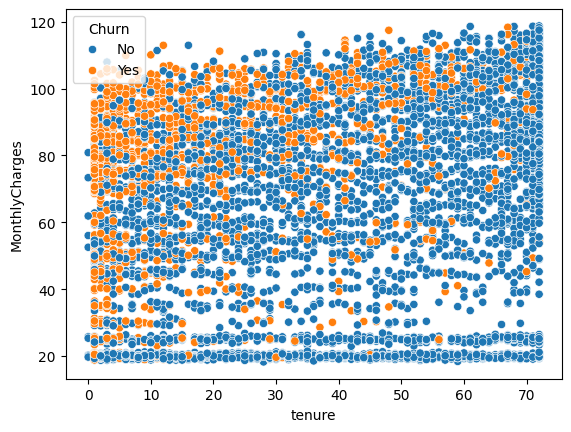

In [17]:
sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn'
)

plt.show()

### Findings
- If the monthly charge is low, customers tend to keep their subscription for a longer period of time.
- If the monthly charges are high for a new customer, they almost immediately cancel the subscription — but long-tenured customers stay even when charges increase.

So keeping monthly charges low at the beginning, then increasing them gradually over time, should help reduce churn.


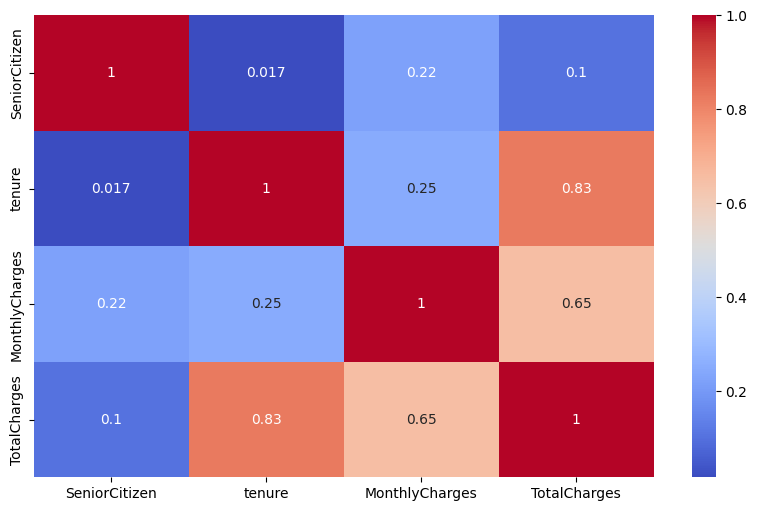

In [18]:
plt.figure(figsize =(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='tenure', ylabel='TotalCharges'>

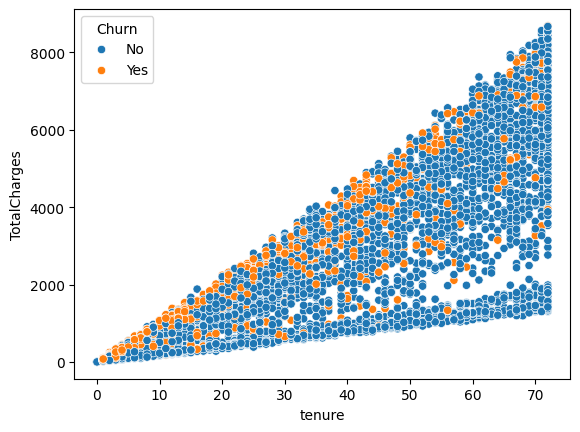

In [19]:
sns.scatterplot(data=df,
                x='tenure',
                y='TotalCharges',
                hue='Churn')

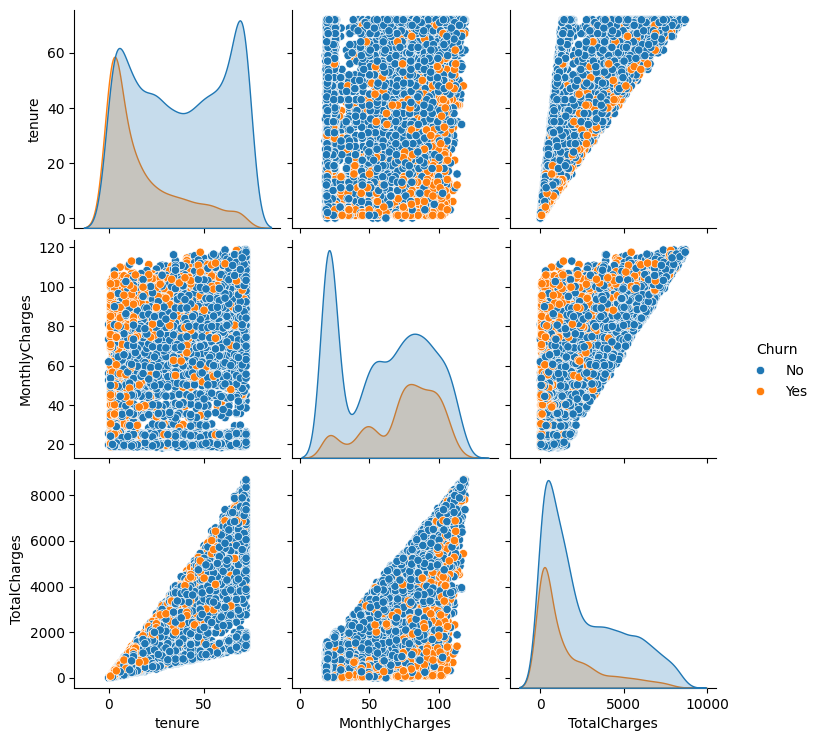

In [20]:
sns.pairplot(
    df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']],
    hue='Churn'
)

plt.show()

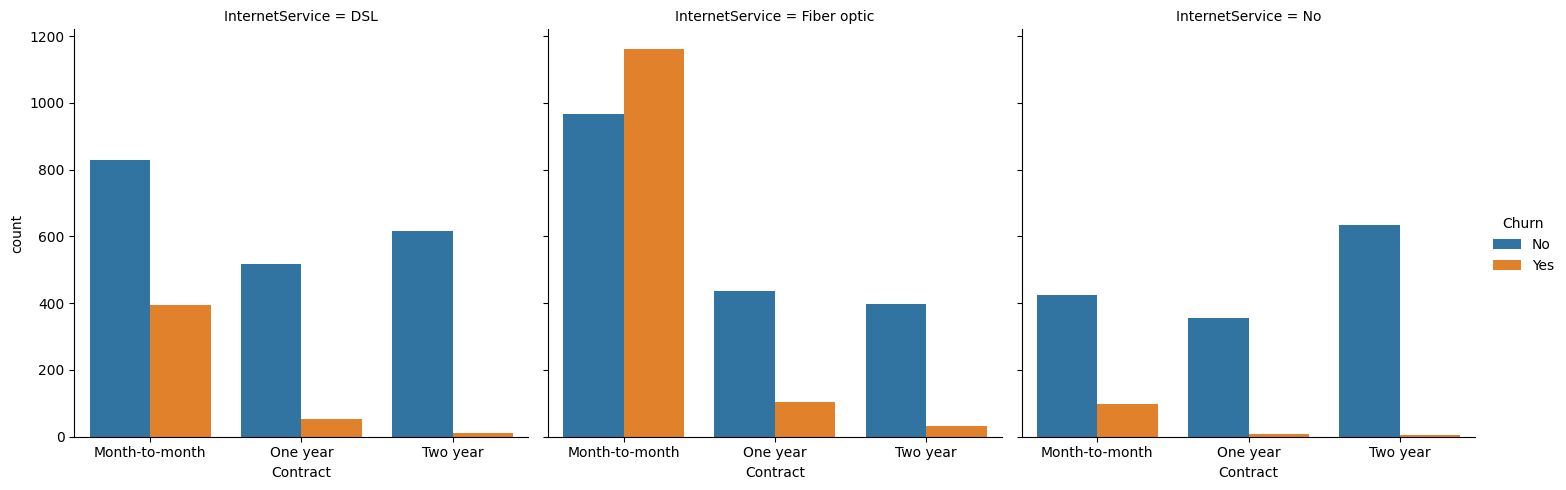

In [21]:
sns.catplot(
    data=df,
    x='Contract',
    hue='Churn',
    col='InternetService',
    kind='count'
)

### Findings
- DSL customers churn relatively rarely across contract types.
- Fiber optic customers on month-to-month contracts churn heavily.

Note: worth investigating the relationship between InternetService and the other service columns (OnlineSecurity, TechSupport, etc.) further.


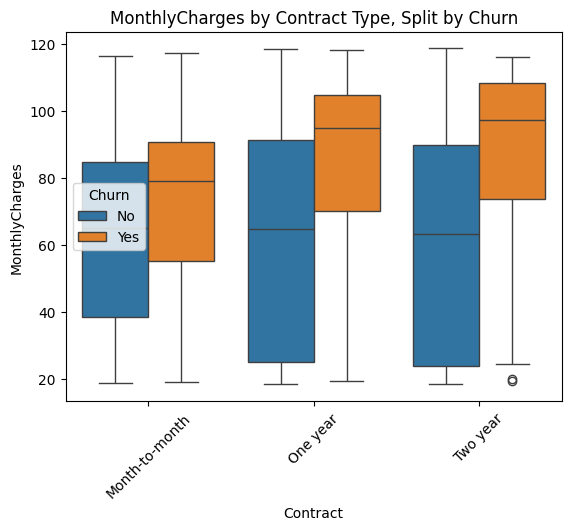

In [22]:
sns.boxplot(
    data=df,
    x='Contract',
    y='MonthlyCharges',
    hue='Churn'
)
plt.title("MonthlyCharges by Contract Type, Split by Churn")
plt.xticks(rotation=45)
plt.show()

### Findings
To reduce churn for month-to-month subscribers, keeping monthly charges in the 60-80 range appears favorable.


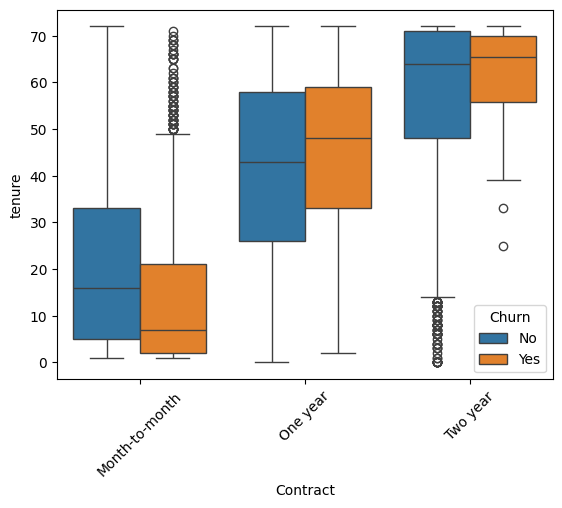

In [23]:
sns.boxplot(
    data=df,
    x='Contract',
    y='tenure',
    hue='Churn'
)

plt.xticks(rotation=45)
plt.show()

### Findings
Low tenure combined with a month-to-month subscription is a risky combination for churn. For One year / Two year contracts, tenure barely separates churners from non-churners — contract type itself dominates.


([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

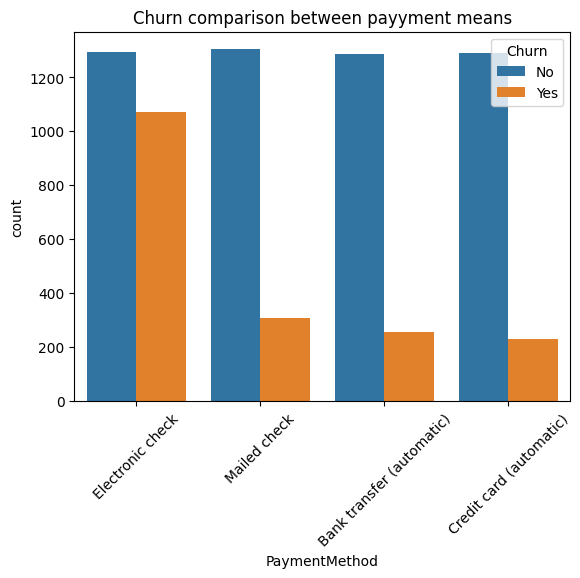

In [24]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Churn comparison between payyment means")
plt.xticks(rotation=45)

### Findings
Customers using Electronic check churn far more than other payment methods. Bank transfer and Credit card (both automatic) show the lowest churn — worth encouraging customers toward automatic payment methods.


In [25]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


### Findings
Churn is very high (almost half) for month-to-month contracts, compared to one-year and two-year contracts.


In [26]:
for col in ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection', 'InternetService']:
  print(col)
  print(pd.crosstab(df[col],df['Churn'], normalize='index'))
  print()

OnlineSecurity
Churn                      No       Yes
OnlineSecurity                         
No                   0.582333  0.417667
No internet service  0.925950  0.074050
Yes                  0.853888  0.146112

TechSupport
Churn                      No       Yes
TechSupport                            
No                   0.583645  0.416355
No internet service  0.925950  0.074050
Yes                  0.848337  0.151663

OnlineBackup
Churn                      No       Yes
OnlineBackup                           
No                   0.600712  0.399288
No internet service  0.925950  0.074050
Yes                  0.784685  0.215315

DeviceProtection
Churn                      No       Yes
DeviceProtection                       
No                   0.608724  0.391276
No internet service  0.925950  0.074050
Yes                  0.774979  0.225021

InternetService
Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic    

In [27]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


/tmp/ipykernel_1758/189664929.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='Set2')


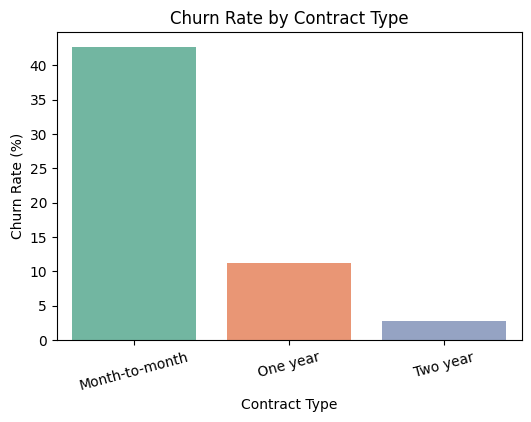

In [28]:
churn_rate = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

plt.figure(figsize=(6,4))
sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='Set2')
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.xticks(rotation=15)
plt.show()

## Final Findings After EDA

- Customers with low tenure on month-to-month contracts tend to churn the most.
- If we can retain new customers through at least a one-year contract, they are far more likely to stay.
- Fiber optic internet customers churn more often than DSL customers.
- Customers without TechSupport or OnlineSecurity tend to churn more.
- Electronic check payment users churn significantly more than automatic payment users.

**Emerging high-risk profile:** month-to-month contract + short tenure + fiber optic internet + no TechSupport/OnlineSecurity + electronic check payment.

**Next step:** feature engineering & encoding, then baseline modeling.


In [29]:
df.drop('customerID',axis=1,inplace=True)

In [30]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
df['TechSupport'].value_counts()

,count
TechSupport,
No,3473
Yes,2044
No internet service,1526


In [32]:
df = df.replace('No internet service','No')

In [33]:
df['InternetService'].value_counts()


,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


In [34]:
df['MultipleLines'] = df['MultipleLines'].replace('No Phone service','No')

In [35]:
df.sample(7)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3382,Male,0,Yes,Yes,72,Yes,Yes,No,No,No,No,No,No,No,Two year,No,Credit card (automatic),25.55,1867.70,No
4091,Female,0,No,No,20,Yes,Yes,DSL,No,Yes,No,Yes,No,Yes,Month-to-month,Yes,Credit card (automatic),68.90,1370.35,No
4903,Female,0,No,No,5,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.80,455.50,Yes
2681,Male,0,Yes,No,46,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,Two year,No,Credit card (automatic),40.40,1842.70,No
3297,Female,0,Yes,No,42,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.35,3571.60,No
2735,Male,1,No,No,52,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),72.95,3829.75,No
5249,Male,0,No,Yes,72,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),67.20,4671.70,No


In [36]:
cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    "OnlineSecurity",
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling',
    'Churn'

]
df[cols]=df[cols].replace({
    'Yes':1,
    'No':0,
    'No phone service':0,
    'No internet service': 0
})
df[cols]=df[cols].astype(int)

/tmp/ipykernel_1758/835970638.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols]=df[cols].replace({


In [37]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6211,Female,0,1,1,5,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Electronic check,85.75,470.95,1
4666,Female,0,0,0,25,1,0,No,0,0,0,0,0,0,Month-to-month,1,Credit card (automatic),19.20,532.10,0
907,Male,0,0,0,19,1,0,DSL,0,1,0,1,0,1,One year,1,Bank transfer (automatic),65.35,1231.85,0
6328,Female,0,0,0,70,1,1,DSL,1,1,1,1,1,1,Two year,0,Credit card (automatic),89.75,6367.20,0
1410,Female,1,0,0,2,1,1,Fiber optic,0,0,0,0,1,1,Month-to-month,1,Electronic check,93.85,170.85,1


In [38]:
df['gender'] = df['gender'].replace({
    'Male':1,
    'Female':0
}).astype(int)

/tmp/ipykernel_1758/1484876690.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({


In [39]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2832,1,0,1,0,40,1,1,DSL,0,1,0,1,1,0,One year,0,Credit card (automatic),70.75,2921.75,0
2156,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,1,Month-to-month,0,Electronic check,80.55,184.10,1
5937,0,1,1,0,8,1,1,Fiber optic,0,0,0,0,0,1,Month-to-month,1,Electronic check,84.00,613.40,1
4308,1,0,0,0,25,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,0,Electronic check,69.75,1729.35,0
6593,1,0,1,0,55,0,0,DSL,0,0,1,1,1,1,Month-to-month,1,Bank transfer (automatic),54.55,2978.30,1


In [40]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [41]:
contract_order = {'Month-to-month':0, 'One year':1, 'Two year':2}
df['Contract'] = df['Contract'].map(contract_order)

In [42]:
df['Contract']

,Contract
0,0
1,1
2,0
3,1
4,0
...,...
7038,1
7039,1
7040,0
7041,0


In [43]:
df = pd.get_dummies(df, columns=['PaymentMethod', 'InternetService'], drop_first=True)

In [44]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,29.85,29.85,0,False,True,False,False,False
1,1,0,0,0,34,1,0,1,0,1,0,0,0,1,0,56.95,1889.50,0,False,False,True,False,False
2,1,0,0,0,2,1,0,1,1,0,0,0,0,0,1,53.85,108.15,1,False,False,True,False,False
3,1,0,0,0,45,0,0,1,0,1,1,0,0,1,0,42.30,1840.75,0,False,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False,True,False


In [45]:
df.shape

(7043, 23)

In [46]:
from sklearn.model_selection import train_test_split
X = df.drop('Churn',axis=1)
y= df['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state=42,stratify=y)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [48]:
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [49]:
from sklearn.linear_model import LogisticRegression
Lr=LogisticRegression(random_state=42,class_weight='balanced')
Lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [50]:
y_pred = Lr.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



###Feature extraction


In [52]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection']  # TechSupport staying separate, as you decided

df['total_services'] = df[service_cols].sum(axis=1)
df.groupby('Churn')['total_services'].mean()

,total_services
Churn,
0,1.064360
1,0.729267


In [53]:
df[['total_services', 'TechSupport']].corr()

,total_services,TechSupport
total_services,1.000000,0.451195
TechSupport,0.451195,1.000000


In [54]:
df.drop(columns=['OnlineSecurity', 'OnlineBackup', 'DeviceProtection'], inplace=True)


### Rebuild features, split, scale & retrain (with total_services + dropped columns)

The steps below redo the split/scale/train using the updated `df` so the engineered `total_services` feature (and the dropped raw columns) actually reach the model.


In [55]:
# Rebuild X, y from the updated df (now includes total_services, excludes the 3 raw cols)
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [56]:
# Redo scaling (fit on train only)
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


In [57]:
# Retrain Logistic Regression with the updated feature set
Lr = LogisticRegression(random_state=42, class_weight='balanced')
Lr.fit(X_train, y_train)
y_pred = Lr.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



In [58]:
from sklearn.preprocessing import StandardScaler

scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)
X_test_scaled = scaler_full.transform(X_test)

In [63]:
Lr = LogisticRegression(random_state=42, class_weight='balanced')
Lr.fit(X_train_scaled, y_train)
y_pred = Lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



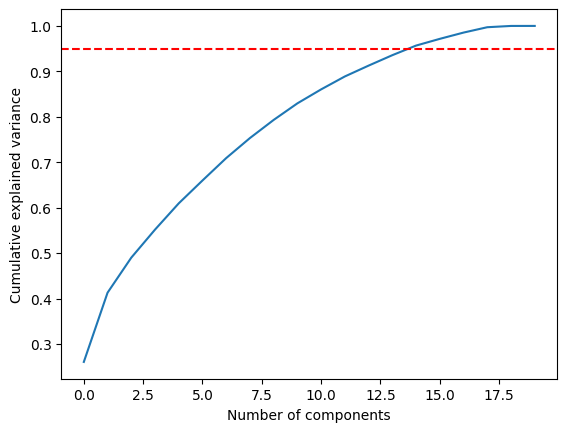

In [61]:
from sklearn.decomposition import PCA

pca_check = PCA().fit(X_train_scaled)

plt.plot(np.cumsum(pca_check.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=0.95, color = 'r', linestyle ='--')
plt.show()


SyntaxError: invalid syntax (3249452352.py, line 1)